In [ ]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import torch.nn as nn

In [ ]:
if torch.cuda.is_available():
    device=torch.device(type="cuda",index=0)
else:
    device=torch.device(type="cpu",index=0)

In [ ]:
train_dataset=datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.76MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.69MB/s]


In [ ]:
test_dataset=datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [ ]:
batch_size=64 # minibatch implementation

train_dl=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [ ]:
test_dl=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [ ]:
class MNISTNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.inh1=nn.Linear(in_features=784, out_features=512) # image fed as flattened (28 x 28) = 784 pixels. 784 x 512 + 512 connections. wx + b
        self.relu=nn.ReLU()
        self.bn1=nn.BatchNorm1d(num_features=512)
        self.h2=nn.Linear(in_features=512, out_features=256)
        self.bn2=nn.BatchNorm1d(num_features=256)
        self.h3=nn.Linear(in_features=256, out_features=128)
        self.bn3=nn.BatchNorm1d(num_features=128)
        self.h4=nn.Linear(in_features=128, out_features=64)
        self.bn4=nn.BatchNorm1d(num_features=64)
        self.h5=nn.Linear(in_features=64, out_features=32)
        self.bn5=nn.BatchNorm1d(num_features=32)
        self.output=nn.Linear(in_features=32, out_features=10)
        self.bn6=nn.BatchNorm1d(num_features=10)

    def forward(self,x):
        x=self.inh1(x)
        x=self.bn1(x)
        x=self.relu(x)
        x=self.h2(x)
        x=self.bn2(x)
        x=self.relu(x)
        x=self.h3(x)
        x=self.bn3(x)
        x=self.relu(x)
        x=self.h4(x)
        x=self.bn4(x)
        x=self.relu(x)
        x=self.h5(x)
        x=self.bn5(x)
        x=self.relu(x)
        x=self.output(x)
        output=self.bn6(x)
        return output

In [ ]:
def train_one_epoch(dataloader, model,loss_fn, optimizer):
    model.train()
    track_loss=0
    num_correct=0
    for i, (imgs, labels) in enumerate(dataloader):
        imgs=torch.reshape(imgs,shape=[-1,784]).to(device)
        labels=labels.to(device)
        pred=model(imgs)

        loss=loss_fn(pred,labels)
        track_loss+=loss.item()
        num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()

        running_loss=round(track_loss/(i+(imgs.shape[0]/batch_size)),2)
        running_acc=round((num_correct/((i*batch_size+imgs.shape[0])))*100,2)

        loss.backward() #gradient for all possible bias and gradient for all possible weights, calucalates gradients for the loss
        optimizer.step()
        optimizer.zero_grad()

        if i%100==0:
            print("Batch:", i+1, "/",len(dataloader), "Running Loss:",running_loss, "Running Accuracy:",running_acc)

    epoch_loss=running_loss
    epoch_acc=running_acc
    return epoch_loss, epoch_acc


In [ ]:
def eval_one_epoch(dataloader, model,loss_fn):
    model.eval()
    track_loss=0
    num_correct=0
    with torch.no_grad():
        for i, (imgs, labels) in enumerate(dataloader):
            imgs=torch.reshape(imgs,shape=[-1,784]).to(device)
            labels=labels.to(device)
            pred=model(imgs)
            loss=loss_fn(pred,labels)
            track_loss+=loss.item()
            num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()
            running_loss=round(track_loss/(i+(imgs.shape[0]/batch_size)),2)
            running_acc=round((num_correct/((i*batch_size+imgs.shape[0])))*100,2)

            if i%100==0:
                print("Batch:", i+1, "/",len(dataloader), "Running Loss:",running_loss, "Running Accuracy:",running_acc)

    epoch_loss=running_loss
    epoch_acc=running_acc
    return epoch_loss, epoch_acc


In [ ]:
model=MNISTNN()
model=model.to(device)
loss_fn=nn.CrossEntropyLoss()
lr=0.001
optimizer=torch.optim.SGD(params=model.parameters(), lr=lr)
n_epochs=1

In [ ]:
for i in range(n_epochs):
    print("Epoch No:",i+1)
    train_epoch_loss, train_epoch_acc=train_one_epoch(train_dl,model,loss_fn,optimizer)
    val_epoch_loss, val_epoch_acc=eval_one_epoch(test_dl,model,loss_fn)
    print("Training:", "Epoch Loss:", train_epoch_loss, "Epoch Accuracy:", train_epoch_acc)
    print("Inference:", "Epoch Loss:", val_epoch_loss, "Epoch Accuracy:", val_epoch_acc)
    print("--------------------------------------------------")

Epoch No: 1
Batch: 1 / 938 Running Loss: 2.64 Running Accuracy: 10.94
Batch: 101 / 938 Running Loss: 1.71 Running Accuracy: 46.74
Batch: 201 / 938 Running Loss: 1.46 Running Accuracy: 58.96
Batch: 301 / 938 Running Loss: 1.32 Running Accuracy: 65.04
Batch: 401 / 938 Running Loss: 1.23 Running Accuracy: 69.16
Batch: 501 / 938 Running Loss: 1.15 Running Accuracy: 72.15
Batch: 601 / 938 Running Loss: 1.1 Running Accuracy: 74.26
Batch: 701 / 938 Running Loss: 1.06 Running Accuracy: 75.9
Batch: 801 / 938 Running Loss: 1.02 Running Accuracy: 77.32
Batch: 901 / 938 Running Loss: 0.98 Running Accuracy: 78.52
Batch: 1 / 157 Running Loss: 0.55 Running Accuracy: 90.62
Batch: 101 / 157 Running Loss: 0.63 Running Accuracy: 90.24
Training: Epoch Loss: 0.97 Epoch Accuracy: 78.89
Inference: Epoch Loss: 0.64 Epoch Accuracy: 90.35
--------------------------------------------------


# Self Work -

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

## A1 - Shallow Network (784 → 128 → 10)


In [ ]:
class FNN_A1(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.out(x)


## A2 - Medium Network (784 → 256 → 128 → 10)

In [ ]:
class FNN_A2(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.out(x)


## A3 - Deep Network (784 → 1024 → 2048 → 1024 → 512 → 10)

In [ ]:
class FNN_A3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
def train_model(model, train_dl, test_dl, epochs=20):
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    history = {
        "train_loss": [], "train_acc": [],
        "test_loss": [], "test_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(train_dl, model, loss_fn, optimizer)
        test_loss, test_acc = eval_one_epoch(test_dl, model, loss_fn)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch+1}: Train Acc={train_acc} | Test Acc={test_acc}")

    return history


## Accuracy vs Loss

In [ ]:
def plot_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["test_acc"], label="Test Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.show()


## Evaluation Metrics

In [ ]:
def evaluate_metrics(model, dataloader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.view(-1, 784).to(device)
            preds = torch.argmax(model(imgs), dim=1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    sensitivity = recall
    specificity = np.mean(
        [cm[i,i] / (cm[i].sum()) for i in range(len(cm))]
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1
    }


## Run all


Training A1-Shallow
Batch: 1 / 938 Running Loss: 2.32 Running Accuracy: 7.81
Batch: 101 / 938 Running Loss: 2.3 Running Accuracy: 11.94
Batch: 201 / 938 Running Loss: 2.29 Running Accuracy: 13.46
Batch: 301 / 938 Running Loss: 2.28 Running Accuracy: 15.25
Batch: 401 / 938 Running Loss: 2.27 Running Accuracy: 18.32
Batch: 501 / 938 Running Loss: 2.26 Running Accuracy: 21.26
Batch: 601 / 938 Running Loss: 2.25 Running Accuracy: 24.25
Batch: 701 / 938 Running Loss: 2.24 Running Accuracy: 27.15
Batch: 801 / 938 Running Loss: 2.23 Running Accuracy: 29.7
Batch: 901 / 938 Running Loss: 2.22 Running Accuracy: 32.22
Batch: 1 / 157 Running Loss: 2.12 Running Accuracy: 48.44
Batch: 101 / 157 Running Loss: 2.11 Running Accuracy: 53.82
Epoch 1: Train Acc=32.99 | Test Acc=53.05
Batch: 1 / 938 Running Loss: 2.12 Running Accuracy: 62.5
Batch: 101 / 938 Running Loss: 2.11 Running Accuracy: 54.19
Batch: 201 / 938 Running Loss: 2.1 Running Accuracy: 55.64
Batch: 301 / 938 Running Loss: 2.09 Running Accu

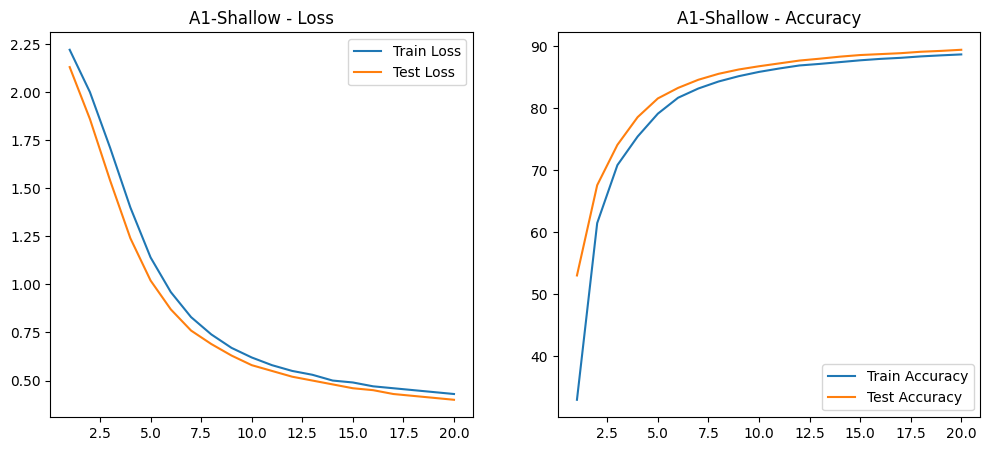


Training A2-Medium
Batch: 1 / 938 Running Loss: 2.3 Running Accuracy: 9.38
Batch: 101 / 938 Running Loss: 2.3 Running Accuracy: 9.9
Batch: 201 / 938 Running Loss: 2.3 Running Accuracy: 10.37
Batch: 301 / 938 Running Loss: 2.3 Running Accuracy: 10.54
Batch: 401 / 938 Running Loss: 2.3 Running Accuracy: 10.95
Batch: 501 / 938 Running Loss: 2.29 Running Accuracy: 11.32
Batch: 601 / 938 Running Loss: 2.29 Running Accuracy: 11.9
Batch: 701 / 938 Running Loss: 2.29 Running Accuracy: 12.23
Batch: 801 / 938 Running Loss: 2.29 Running Accuracy: 12.67
Batch: 901 / 938 Running Loss: 2.29 Running Accuracy: 12.99
Batch: 1 / 157 Running Loss: 2.27 Running Accuracy: 18.75
Batch: 101 / 157 Running Loss: 2.26 Running Accuracy: 17.87
Epoch 1: Train Acc=13.14 | Test Acc=17.67
Batch: 1 / 938 Running Loss: 2.26 Running Accuracy: 21.88
Batch: 101 / 938 Running Loss: 2.27 Running Accuracy: 18.07
Batch: 201 / 938 Running Loss: 2.26 Running Accuracy: 18.29
Batch: 301 / 938 Running Loss: 2.26 Running Accuracy:

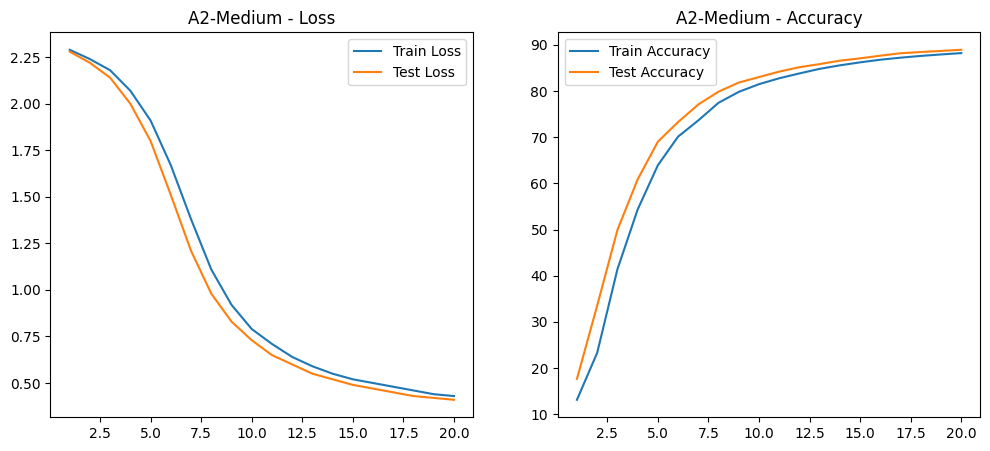


Training A3-Deep
Batch: 1 / 938 Running Loss: 2.32 Running Accuracy: 12.5
Batch: 101 / 938 Running Loss: 2.18 Running Accuracy: 35.29
Batch: 201 / 938 Running Loss: 2.08 Running Accuracy: 49.08
Batch: 301 / 938 Running Loss: 1.97 Running Accuracy: 56.67
Batch: 401 / 938 Running Loss: 1.87 Running Accuracy: 61.6
Batch: 501 / 938 Running Loss: 1.77 Running Accuracy: 64.97
Batch: 601 / 938 Running Loss: 1.67 Running Accuracy: 67.65
Batch: 701 / 938 Running Loss: 1.59 Running Accuracy: 69.76
Batch: 801 / 938 Running Loss: 1.51 Running Accuracy: 71.43
Batch: 901 / 938 Running Loss: 1.43 Running Accuracy: 72.91
Batch: 1 / 157 Running Loss: 0.64 Running Accuracy: 89.06
Batch: 101 / 157 Running Loss: 0.73 Running Accuracy: 87.5
Epoch 1: Train Acc=73.41 | Test Acc=87.54
Batch: 1 / 938 Running Loss: 0.67 Running Accuracy: 92.19
Batch: 101 / 938 Running Loss: 0.75 Running Accuracy: 85.35
Batch: 201 / 938 Running Loss: 0.71 Running Accuracy: 86.28
Batch: 301 / 938 Running Loss: 0.68 Running Accur

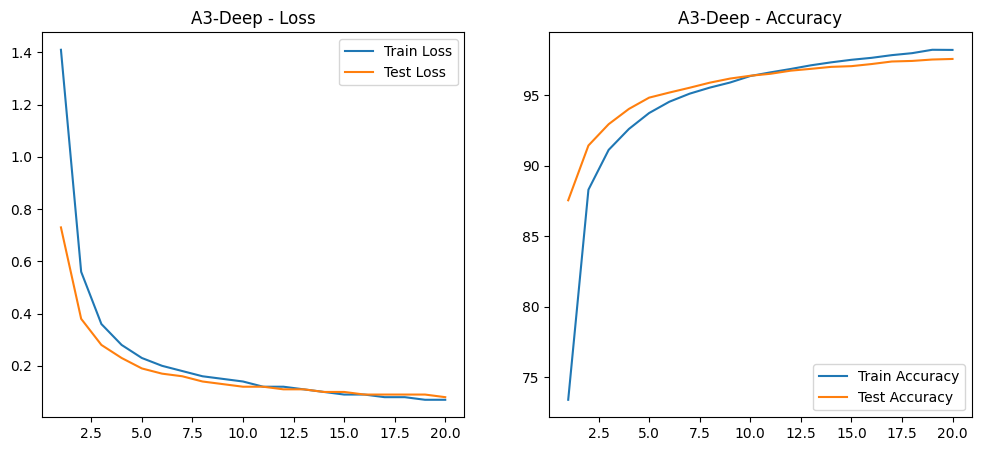

In [ ]:
models = {
    "A1-Shallow": FNN_A1(),
    "A2-Medium": FNN_A2(),
    "A3-Deep": FNN_A3()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}")
    history = train_model(model, train_dl, test_dl)
    plot_curves(history, name)
    results[name] = evaluate_metrics(model, test_dl)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def show_final_results(models, test_dl):
    for name, model in models.items():
        print("\n" + "="*60)
        print(f"MODEL: {name}")
        print("="*60)

        model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for imgs, labels in test_dl:
                imgs = imgs.view(-1, 784).to(device)
                outputs = model(imgs)
                preds = torch.argmax(outputs, dim=1)

                y_true.extend(labels.numpy())
                y_pred.extend(preds.cpu().numpy())

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)

        # Metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        f1 = f1_score(y_true, y_pred, average='macro')

        # Sensitivity & Specificity
        sensitivity = recall
        specificity = np.mean([
            cm[i, i] / cm[i].sum() if cm[i].sum() != 0 else 0
            for i in range(len(cm))
        ])

        # Print metrics
        print(f"Accuracy     : {accuracy:.4f}")
        print(f"Precision    : {precision:.4f}")
        print(f"Recall       : {recall:.4f}")
        print(f"Sensitivity  : {sensitivity:.4f}")
        print(f"Specificity  : {specificity:.4f}")
        print(f"F1 Score     : {f1:.4f}")

        # Plot Confusion Matrix
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.show()



MODEL: A1-Shallow
Accuracy     : 0.8947
Precision    : 0.8934
Recall       : 0.8930
Sensitivity  : 0.8930
Specificity  : 0.8930
F1 Score     : 0.8928


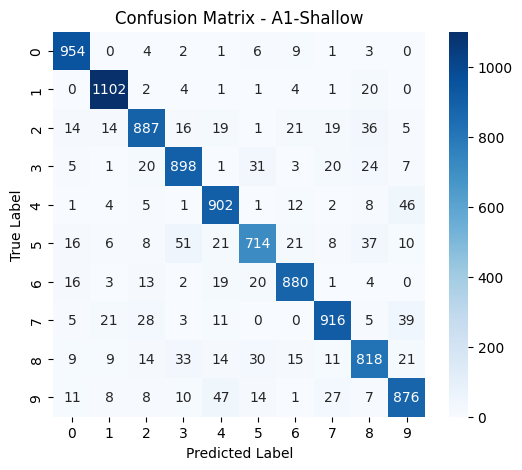


MODEL: A2-Medium
Accuracy     : 0.8895
Precision    : 0.8876
Recall       : 0.8876
Sensitivity  : 0.8876
Specificity  : 0.8876
F1 Score     : 0.8873


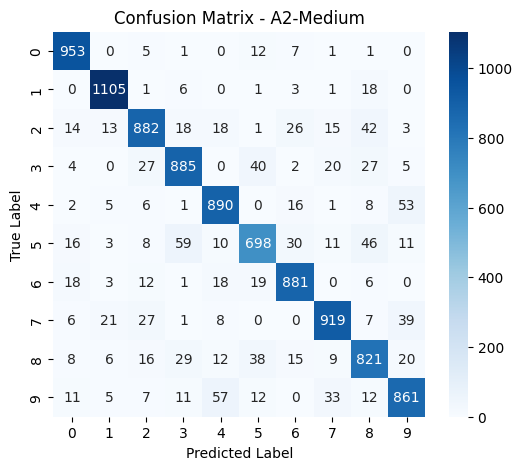


MODEL: A3-Deep
Accuracy     : 0.9755
Precision    : 0.9753
Recall       : 0.9753
Sensitivity  : 0.9753
Specificity  : 0.9753
F1 Score     : 0.9753


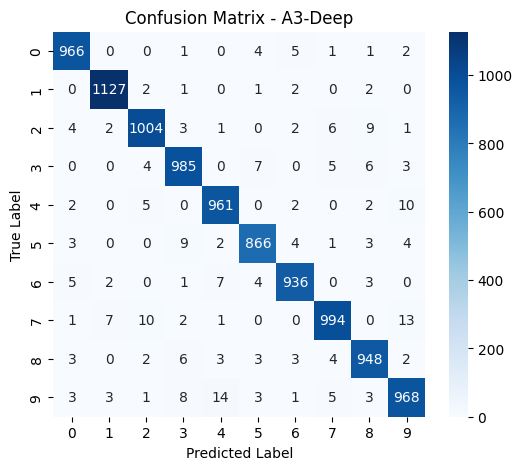

In [ ]:
show_final_results(models, test_dl)


## Analysis


1.  A1 – Shallow Network

Achieved an accuracy of 89.47%

Precision, recall, sensitivity, specificity, and F1-score are all around 0.89

Shows reasonable performance with limited depth

Suffers from underfitting, as the model capacity is insufficient to capture complex digit variations

Fast training but limited representational power

-------------------------------------------------------

2.  A2 – Medium Network

Achieved an accuracy of 88.95%, slightly lower than A1

Metrics are consistently around 0.887

Despite increased depth, performance did not improve

Indicates suboptimal learning possibly due to:

A. Lack of batch normalization

B. Optimization difficulty with SGD

C. Insufficient regularization or tuning

Demonstrates that increasing depth alone does not guarantee better performance

-------------------------------------------------------

3.  A3 – Deep Network

Achieved the highest accuracy of 97.55%

Precision, recall, sensitivity, specificity, and F1-score are all ~0.975

Clear improvement over shallow and medium models

Benefits from:

A. Greater depth

B. Batch normalization

C. Better hierarchical feature learning

Exhibits strong generalization with minimal performance gap across metrics

| Architecture     | Accuracy   | Precision  | Recall     | Sensitivity | Specificity | F1 Score   |
| ---------------- | ---------- | ---------- | ---------- | ----------- | ----------- | ---------- |
| **A1 – Shallow** | 0.8947     | 0.8934     | 0.8930     | 0.8930      | 0.8930      | 0.8928     |
| **A2 – Medium**  | 0.8895     | 0.8876     | 0.8876     | 0.8876      | 0.8876      | 0.8873     |
| **A3 – Deep**    | **0.9755** | **0.9753** | **0.9753** | **0.9753**  | **0.9753**  | **0.9753** |
